# Linear Regression Assumptions — Visual Checks (Seaborn Whitegrid)

This notebook demonstrates how to **check linear regression assumptions visually** using Seaborn and Matplotlib — no statistical tests.

We use Seaborn's built-in **mpg dataset**, treating `mpg` as the dependent variable and all other numeric features (plus dummy variables for `origin`) as predictors.

**Assumptions Checked:**
1. Linearity  
2. Mean of Residuals = 0  
3. Homoscedasticity  
4. Normality of Residuals  
5. No Autocorrelation  
6. No Multicollinearity

## 1. Setup and Data Overview

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

# Load dataset
df = sns.load_dataset('mpg').dropna()
df['origin'] = df['origin'].astype('category')
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

display(df.head())
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,name,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,0,1


Shape: (392, 10)

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
name            0
origin_japan    0
origin_usa      0
dtype: int64


### Pairplot and Correlation Overview

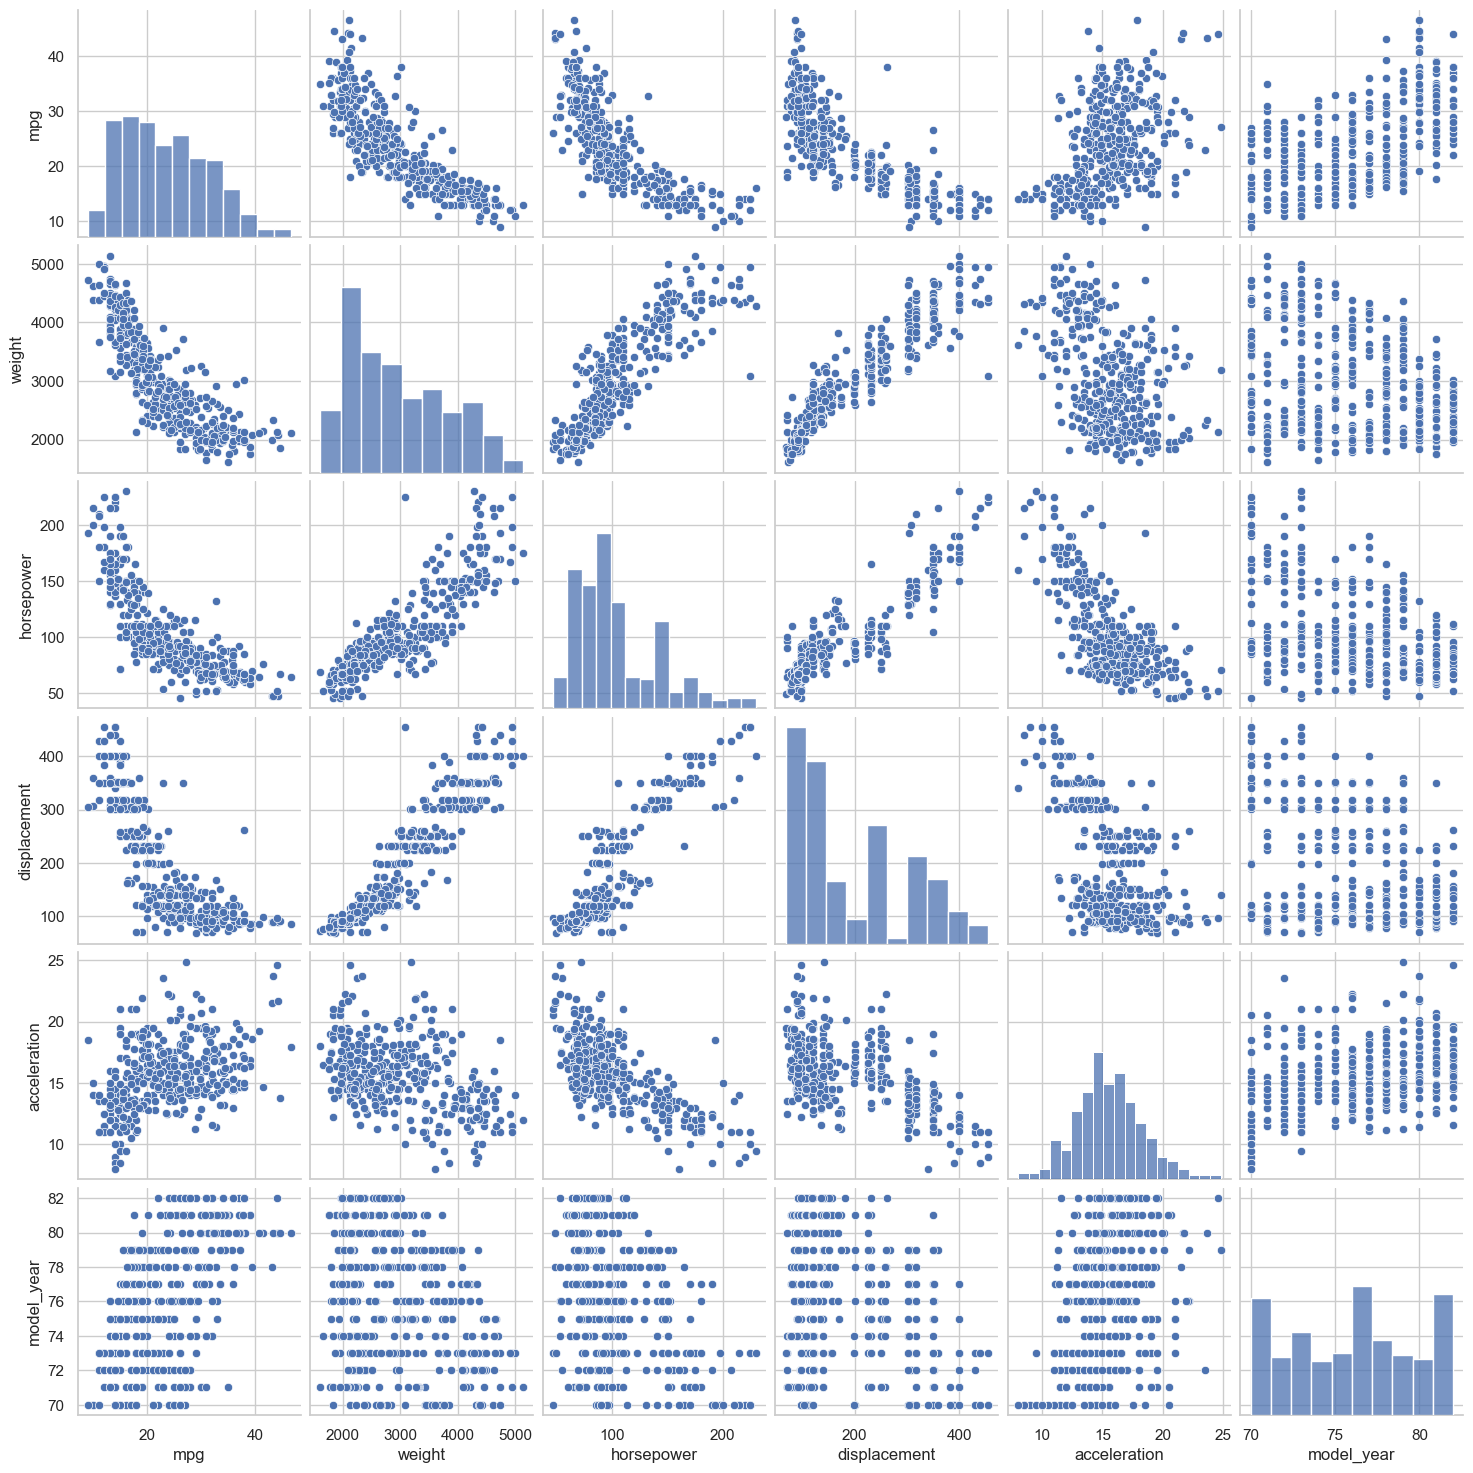

C:\Users\GIM\AppData\Local\Temp\ipykernel_22908\2811684205.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)


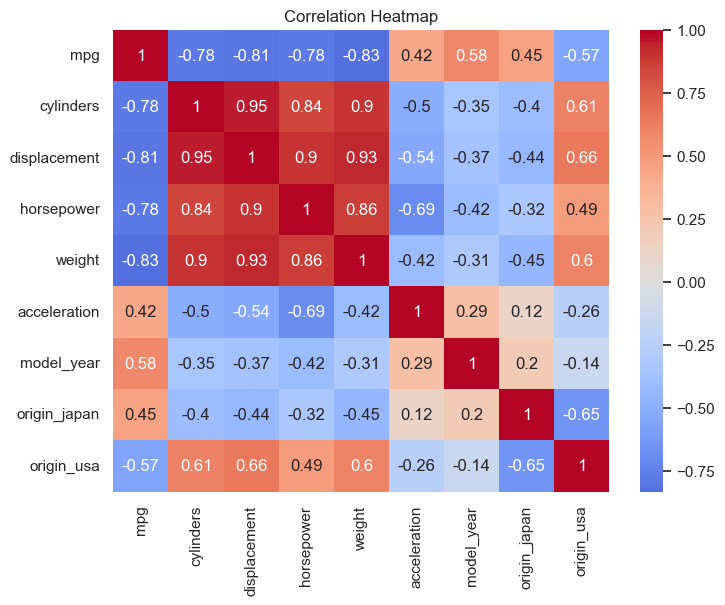

In [2]:
sns.pairplot(df[['mpg','weight','horsepower','displacement','acceleration','model_year']])
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

## 2. Fit Base Linear Regression Model

In [4]:
df = df.drop(columns=['name'])

X = df.drop(columns=['mpg'])
y = df['mpg']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

## 3. Check Each Assumption Visually

### 1️⃣ Linearity

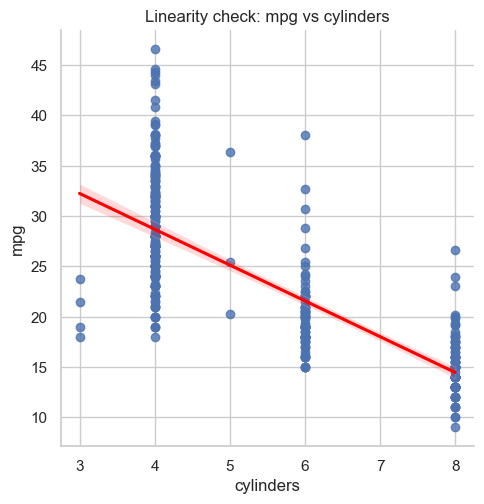

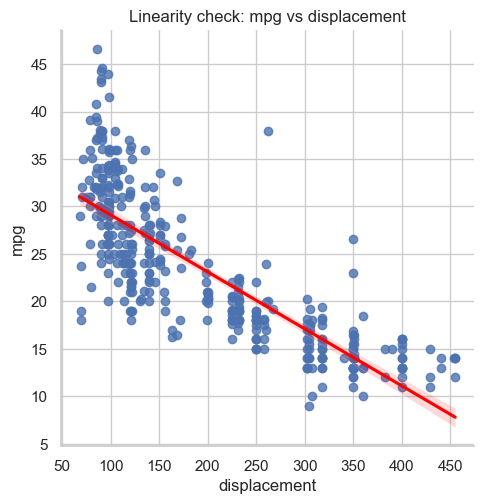

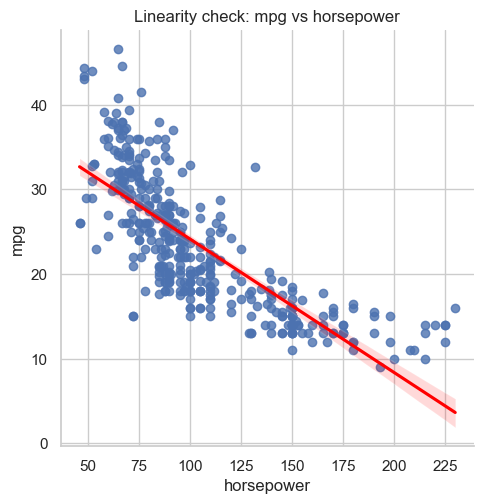

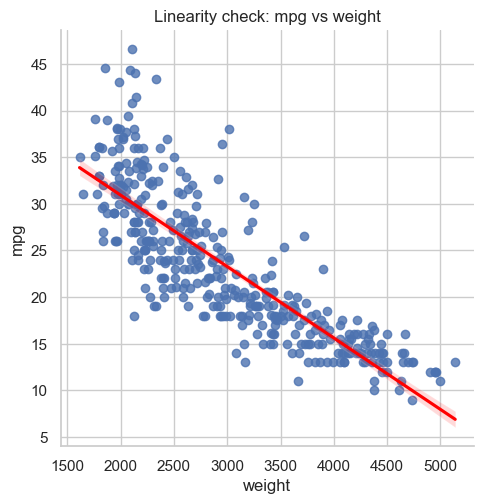

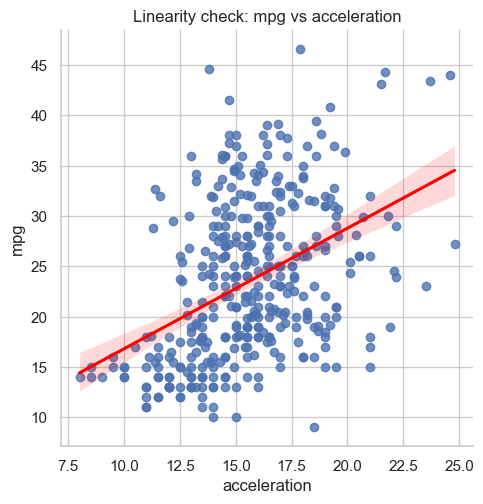

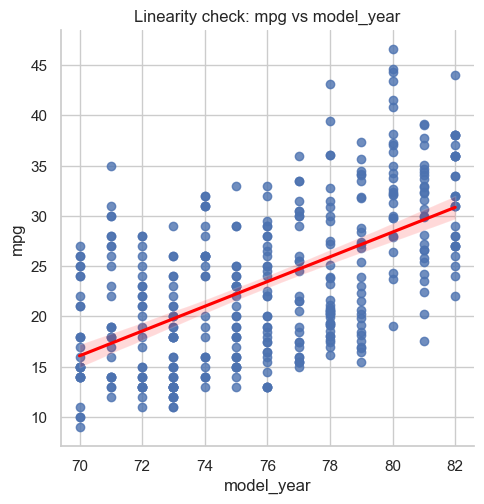

In [5]:
for col in X.columns[:6]:  # numeric predictors
    sns.lmplot(x=col, y='mpg', data=df, line_kws={'color':'red'})
    plt.title(f'Linearity check: mpg vs {col}')
    plt.show()
# Observation: Curved patterns for weight, displacement, horsepower indicate nonlinearity.

### 2️⃣ Mean of Residuals = 0

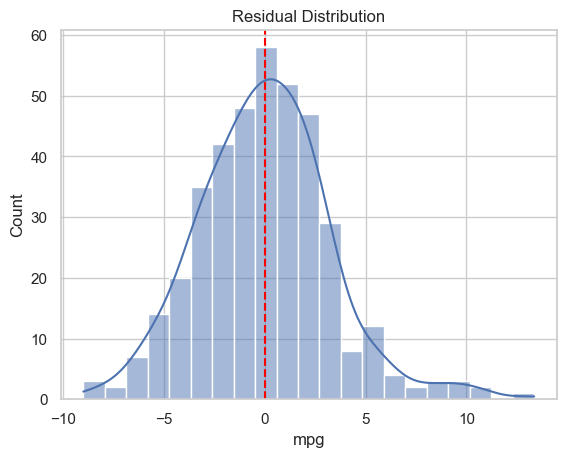

Mean of residuals: 1.2797019679760988e-14


In [6]:
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution")
plt.show()
print("Mean of residuals:", residuals.mean())
# Observation: Centered around zero.

### 3️⃣ Homoscedasticity (Equal Variance)

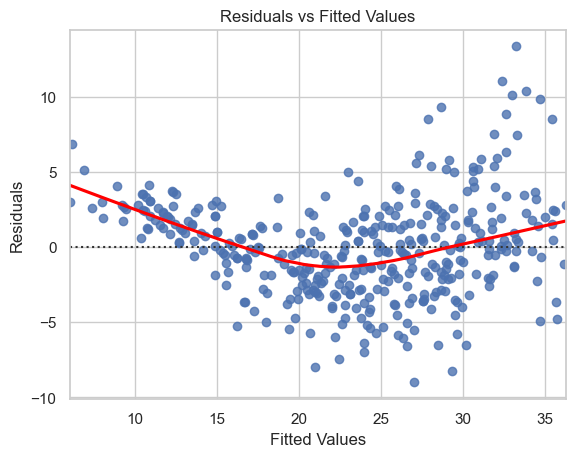

In [7]:
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color':'red'})
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()
# Observation: Funnel pattern → heteroscedasticity present.

### 4️⃣ Normality of Residuals

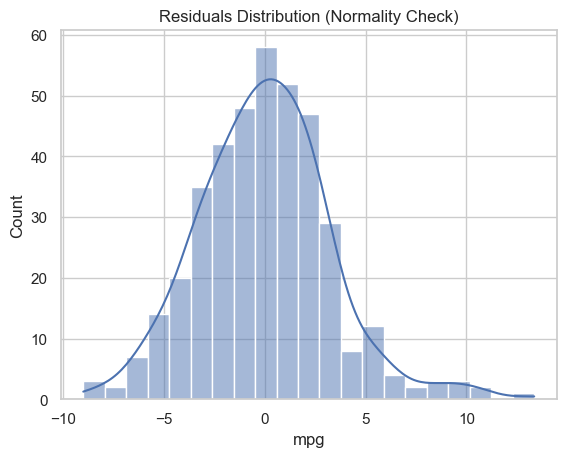

In [8]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution (Normality Check)")
plt.show()
# Observation: Right-skewed residuals → not perfectly normal.

### 5️⃣ No Autocorrelation

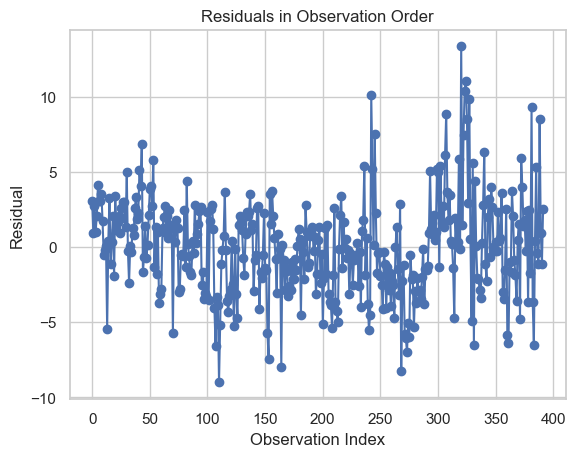

In [9]:
plt.plot(residuals.values, marker='o')
plt.title("Residuals in Observation Order")
plt.xlabel("Observation Index")
plt.ylabel("Residual")
plt.show()
# Observation: No visible pattern → likely uncorrelated.

### 6️⃣ No Multicollinearity

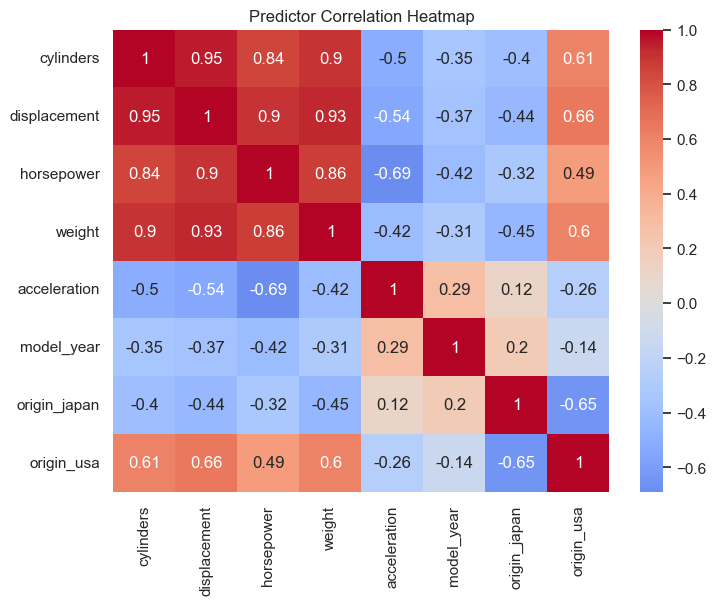

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Predictor Correlation Heatmap")
plt.show()
# Observation: Strong correlation between weight, displacement, horsepower → multicollinearity risk.